In [1]:
library(ArchR)
library(BSgenome.Hsapiens.UCSC.hg38)
set.seed(1)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
suppressPackageStartupMessages({
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(tidyr)
    library(purrr)
    library(data.table)
    library(reticulate)
    # plan("multicore", workers = 12)
    # options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [3]:
addArchRThreads(threads = 32) 
addArchRGenome("hg38")

Setting default number of Parallel threads to 32.

Setting default genome to Hg38.



### Load DMG atlas ATAC (matching Signac filtered cells)

In [3]:
dmg_atlas <- loadArchRProject('./ArchRSubset/')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

### Plotting Sample Statistics from an ArchRProject

Length of unique values greater than palette, interpolating..

1 




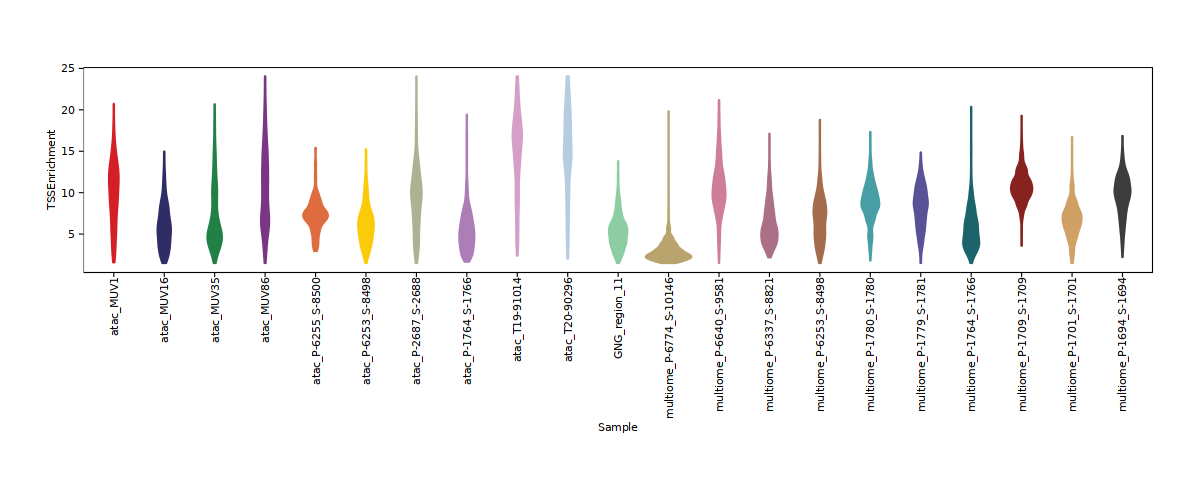

In [7]:
options(repr.plot.height = 4, repr.plot.width = 10)
# Make a violin plot for each sample for the TSS enrichment scores
p1 <- plotGroups(
    ArchRProj = dmg_atlas, 
    groupBy = "Sample", 
    colorBy = "cellColData", 
    name = "TSSEnrichment",
    plotAs = "violin",
    alpha = 1,
    addBoxPlot = FALSE
   )
p1

Length of unique values greater than palette, interpolating..

1 




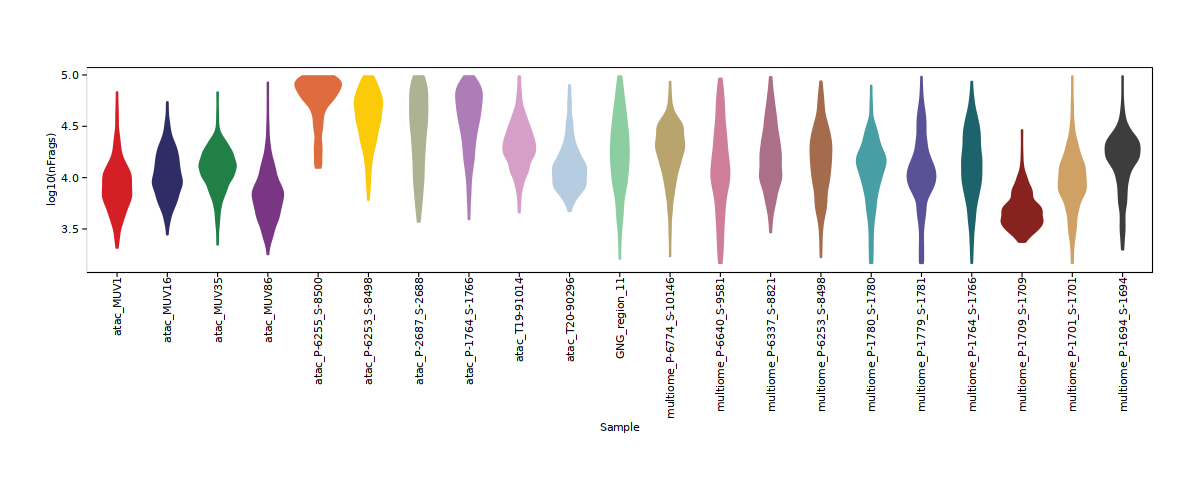

In [8]:
options(repr.plot.height = 4, repr.plot.width = 10)
# Make a violin plot for each sample for the TSS enrichment scores
p2 <- plotGroups(
    ArchRProj = dmg_atlas, 
    groupBy = "Sample", 
    colorBy = "cellColData", 
    name = "log10(nFrags)",
    plotAs = "violin",
    alpha = 1,
    addBoxPlot = FALSE
   )
p2

In [21]:
plotPDF(p1,p2, name = "QC-Sample-Statistics.pdf", ArchRProj = dmg_atlas, addDOC = FALSE)

Plotting Ggplot!

Plotting Ggplot!



### Plotting Sample Fragment Size Distribution and TSS Enrichment Profiles

ArchR logging to : ArchRLogs/ArchR-plotFragmentSizes-8799644b57069-Date-2024-02-18_Time-11-45-52.log
If there is an issue, please report to github with logFile!

ArchR logging successful to : ArchRLogs/ArchR-plotFragmentSizes-8799644b57069-Date-2024-02-18_Time-11-45-52.log

Length of unique values greater than palette, interpolating..



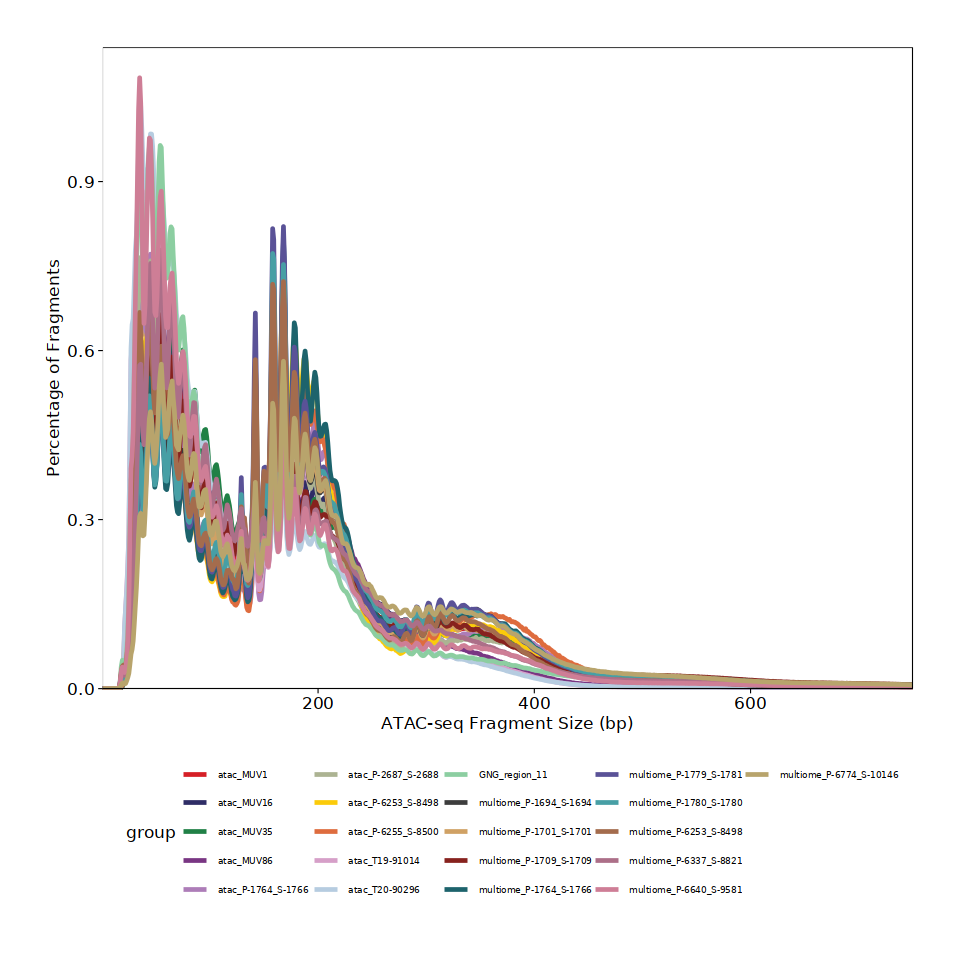

In [22]:
options(repr.plot.height = 8, repr.plot.width = 8)
p1 <- plotFragmentSizes(ArchRProj = dmg_atlas)
p1

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-8799633c12a4e-Date-2024-02-18_Time-11-58-01.log
If there is an issue, please report to github with logFile!

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-8799633c12a4e-Date-2024-02-18_Time-11-58-01.log

Length of unique values greater than palette, interpolating..



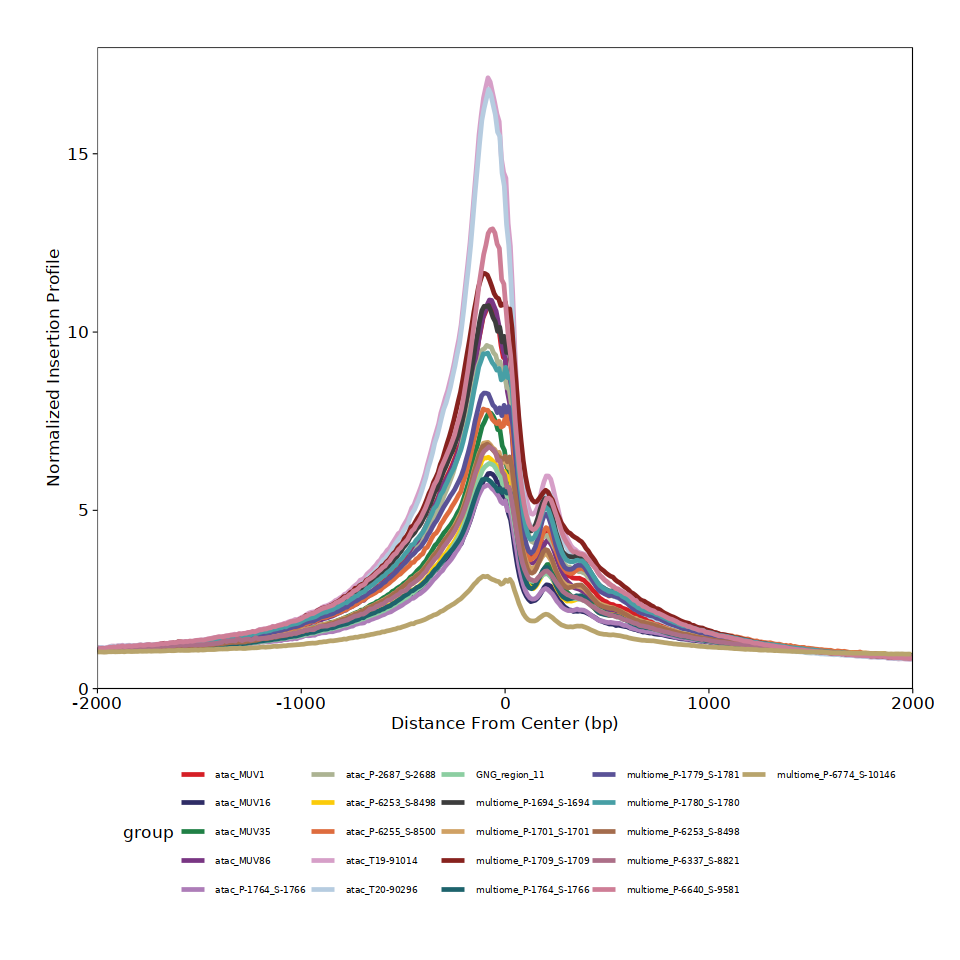

In [23]:
p2 <- plotTSSEnrichment(ArchRProj = dmg_atlas)
p2

In [24]:
plotPDF(p1,p2, name = "QC-Sample-FragSizes-TSSProfile.pdf", ArchRProj = dmg_atlas, addDOC = FALSE, width = 5, height = 5)

Plotting Ggplot!

Plotting Ggplot!

